## Notebook Accompanying "Training Language Models to Explain Their Own Computations"

**Citation:**

Li, B. Z., Guo, Z. C., Huang, V., Steinhardt, J., & Andreas, J. (2025). *Training Language Models to Explain Their Own Computations*. arXiv:2511.08579. https://arxiv.org/abs/2511.08579

### Contents

This notebook replicates and gives working examples of the input ablation and activation patching methods for using the explainer model.

Section one of the notebook covers the activation patching of 2.3, section two covers the input ablation of 2.4, and section three covers the explainer $\to$ simulator training loop detailed in figure 2 and section 2.2.

We use Qwen3 as both the explainer and simulator to avoid mismatched dimensions. We also only LoRA fine-tune the explainer, because a full fine-tuning on all parameters is not possible on Colab. For this reason, we also quantize the model (although the unquantized version will work with an A100).

### Config and Necessary Packages

In [1]:
MODEL_ID = "Qwen3-1.7B"                                               # Qwen3-0.6B, Qwen3-1.7B, Qwen3-4B, Qwen3-8B
USE_4BIT = False                                                      # For T4/L4 Colab GPU, can use 16 bit with A100
MAX_SEQ_LEN = 512                                                     # good for L4
N_TRAIN = 128                                                         # dataset size for LoRA training (128, 512, 2048, 8192)
N_TRAIN_VALUES = [128, 256, 512, 1024, 2048, 4096, 8192, 16384]       # sweep points for the N_TRAIN comparison section
LORA_R = 16                                                           # LoRA rank for QLoRA (16-64)
SEED = 67                                                             # for reproducibility
OUTPUT_DIR = f"explanations_interp/{MODEL_ID}/no_quant"               # directory on gdrive

In [2]:
%pip install transformers
%pip install peft
%pip install bitsandbytes
%pip install trl
%pip install datasets
%pip install accelerate
%pip install scikit-learn
%pip install pandas
%pip install matplotlib
%pip install -U torchao

In [3]:
import os

# you should be prompted to connect your gdrive and hf
from google.colab import drive
drive.mount("/content/drive")

from google.colab import userdata
from huggingface_hub import login
login(token=userdata.get('HF_TOKEN'))

# you should not be prompted to redownloaded the models to gdrive
os.environ['HF_HOME'] = '/content/drive/MyDrive/hf_cache'
os.environ['HF_HUB_CACHE'] = '/content/drive/MyDrive/hf_cache/hub'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Model Set Up and Tokenizer

In [4]:
MODEL_IDS = {
    "Qwen3-0.6B": "Qwen/Qwen3-0.6B",
    "Qwen3-1.7B": "Qwen/Qwen3-1.7B",
    "Qwen3-4B": "Qwen/Qwen3-4B",
    "Qwen3-8B": "Qwen/Qwen3-8B"
}
model_id = MODEL_IDS[MODEL_ID]

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

compute_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16  # bf16, fp16 on T4

tokenizer = AutoTokenizer.from_pretrained(model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

if USE_4BIT:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=compute_dtype,
        bnb_4bit_use_double_quant=True,
    )

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto",
    )

else:
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype = compute_dtype,
        device_map="auto"
    )

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

model.safetensors.index.json:   0%|          | 0.00/25.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

### Placeholder Token for Activation Patching

In [ ]:
PLACEHOLDER_TOKEN = "<|patch_v|>"
FEATURE_START_TOKEN = "<|feat_s|>"
FEATURE_END_TOKEN = "<|feat_e|>"
num_added = tokenizer.add_special_tokens({"additional_special_tokens": [PLACEHOLDER_TOKEN, FEATURE_START_TOKEN, FEATURE_END_TOKEN]})
if num_added > 0:
    model.resize_token_embeddings(len(tokenizer)) # adjusting model to add placeholder + feature span tokens
placeholder_id = tokenizer.convert_tokens_to_ids(PLACEHOLDER_TOKEN)
feature_start_id = tokenizer.convert_tokens_to_ids(FEATURE_START_TOKEN)
feature_end_id = tokenizer.convert_tokens_to_ids(FEATURE_END_TOKEN)
FEATURE_SPAN = f"{FEATURE_START_TOKEN}{PLACEHOLDER_TOKEN}{FEATURE_END_TOKEN}"  # renders as [s]v[e] in the templates


## Input Ablation

Input ablation is the process of removing tokens in a prompt given to a model. Given a question with a hint we record a models answers. We then record the answers when the input is ablated (the authors collect these answers in the dataset below). We then train an "explainer" model to predict whether or not the answer would change upon ablation. The explainer is the same base model as the one answering questions, but with SFT on the ablation dataset.

See section 2.4 and appendix F for more technical details.

In [6]:
# inpute ablation, loading pretrained model
from datasets import load_dataset
dataset = load_dataset("Transluce/input_ablation_qwen3_8b_mmlu_hint", split="train")
dataset = dataset.shuffle(seed=SEED)

README.md:   0%|          | 0.00/2.56k [00:00<?, ?B/s]

### Prompts

Per appendix F the prompts for the input ablations are formatted as:

>[SYSTEM]
>
>The following are multiple choice questions (with a correct answer). Output only the answer letter (A, B, C, or D) and nothing else, in the format Answer: x, where x is one of A, B,C, or D.
>
>[USER]
>Question: c
>Hint: x'
>
>[ASSISTANT]
>If the hint were removed how would the assistant answer change?

[SYSTEM], [USER], and [ASSISTANT] are the role tokens. We only use the chat function of the explainer model, which is trained to predict one of these two outputs.

>The most likely output would change to <<<Answer: X>>>.
>
>The output would remain unchanged from <<<Answer: X'>>>.

In [7]:
def add_derived_fields(example):
    return {
        "q": example["original_user_prompt"].strip(),
        "hint": example["hint"].split(": ", 1)[-1],  # dataset's hint field is prefixed "Hint: ...", build_user_turn adds its own prefix
        "answer_no_hint": example["zeroshot_prediction"],
        "answer_with_hint": example["random_hint_prediction"],
    }

dataset = dataset.map(add_derived_fields)

example = dataset[0]
print(example) # run to check which fields match to c, hint, M(c), M(c,x') then adjust build_example accordingly

## setting up the prompt format for tokenizer and training
SYSTEM_PROMPT = (
    "The following are multiple choice questions (with a correct answer). "
    "Output only the answer letter (A, B, C, or D) and nothing else, "
    "in the format Answer: x, where x is one of A, B, C, or D.")

def build_user_turn(q, hint):
    """
    constructing user prompt per the paper appendix F
    """
    return f"Question: {q}\nHint: {hint}\n\nIf the hint were removed how would the assistant answer change?"

def build_target_text(answer_no_hint, answer_with_hint):
    """
    constructing possible target response prompts per appendix F
    """
    if answer_no_hint != answer_with_hint:
        target_text = f"The most likely output would change to <<<Answer: {answer_no_hint}>>>."
    else:
        target_text = f"The output would remain unchanged from <<<Answer: {answer_no_hint}>>>."
    return target_text

def build_example(q, hint, answer_no_hint, answer_with_hint):
    """
    returns the plain text example given each component.
    verify that prompt is accurate
    """
    return build_user_turn(q, hint), build_target_text(answer_no_hint, answer_with_hint)

print(build_example(example["q"], example["hint"], example["answer_no_hint"], example["answer_with_hint"]))

def to_messages(example):
    """
    use for formatting dataset correctly for training run
    """
    return {"messages": [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": build_user_turn(example["q"], example["hint"])},
        {"role": "assistant", "content": build_target_text(example["answer_no_hint"], example["answer_with_hint"])}
    ]}

# dataset to the correct format
dataset = dataset.map(to_messages)


{'index': 3114, 'question': 'Which of the following correctly lists the individual intermolecular attractive forces from the strongest to the weakest?', 'choices': ['Induced dipole < dipole-dipole < hydrogen bond', 'Hydrogen bond < dipole-dipole < induced dipole', 'Induced dipole < hydrogen bond < dipole-dipole', 'Dipole-dipole < hydrogen bond < induced dipole'], 'correct_answer': 'B', 'zeroshot_prediction': 'C', 'random_hint_prediction': 'C', 'hint_token_ids': [34], 'original_prompt_full': '<|im_start|>system\nThe following are multiple choice questions (with a correct answer). Output only the answer letter (A, B, C, or D) and nothing else, in the format Answer: x, where x is one of A, B, C, or D.<|im_end|>\n<|im_start|>user\nWhich of the following correctly lists the individual intermolecular attractive forces from the strongest to the weakest?\nA. Induced dipole < dipole-dipole < hydrogen bond\nB. Hydrogen bond < dipole-dipole < induced dipole\nC. Induced dipole < hydrogen bond < di

In [8]:
# sanity check: render the prompt exactly as the tokenizer's chat template will, and confirm
inference_messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user", "content": build_user_turn(example["q"], example["hint"])},
]
print(tokenizer.apply_chat_template(
    inference_messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False,
))


<|im_start|>system
The following are multiple choice questions (with a correct answer). Output only the answer letter (A, B, C, or D) and nothing else, in the format Answer: x, where x is one of A, B, C, or D.<|im_end|>
<|im_start|>user
Question: Which of the following correctly lists the individual intermolecular attractive forces from the strongest to the weakest?
A. Induced dipole < dipole-dipole < hydrogen bond
B. Hydrogen bond < dipole-dipole < induced dipole
C. Induced dipole < hydrogen bond < dipole-dipole
D. Dipole-dipole < hydrogen bond < induced dipole
Hint: The answer is C

If the hint were removed how would the assistant answer change?<|im_end|>
<|im_start|>assistant
<think>

</think>




### Training Setup

Functions for configuring and running LoRA SFT on the input ablation dataset. Completes a single training run at the select `N_TRAIN`.

In [9]:
import gc, json
from trl import SFTTrainer, SFTConfig
from peft import LoraConfig, TaskType

EVAL_SIZE = 128  # held out from every run so N_TRAIN comparisons use the same eval set

eval_dataset = dataset.select(range(len(dataset) - EVAL_SIZE, len(dataset)))

def load_fresh_base_model():
    """
    loading new base model
    used in training and evaluation of base model
    """
    m = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config if USE_4BIT else None,
        torch_dtype=None if USE_4BIT else compute_dtype,
        device_map="auto",
    )
    if m.get_input_embeddings().weight.shape[0] != len(tokenizer):
        m.resize_token_embeddings(len(tokenizer))  # re-apply the <|patch_v|> resize from earlier
    return m

def run_training(n_train):
    """
    trains input ablation explainer model
    n_train number of training examples
    """
    tokenizer.padding_side = "right"  # standard for training; switched from "left" set earlier for generation
    train_subset = dataset.select(range(n_train))
    base_model = load_fresh_base_model()  # fresh weights each call so LoRA adapters don't stack across runs

    save_dir = f"/content/drive/MyDrive/{OUTPUT_DIR}/n_train_{n_train}"
    trainer = SFTTrainer(
        model=base_model,
        args=SFTConfig(
            output_dir=save_dir,
            # masking loss to completion tokens only
            max_length=MAX_SEQ_LEN, assistant_only_loss=True, packing = False,
            # batching for small dataset (128-8k) and short sequences < 512
            per_device_train_batch_size=4, gradient_accumulation_steps=4,
            # optimizer schedule for LoRA
            learning_rate=1e-4, lr_scheduler_type="cosine", warmup_ratio=0.03, optim="paged_adamw_8bit",
            # T4 doesn't support bf16
            bf16=torch.cuda.is_bf16_supported(), fp16=not torch.cuda.is_bf16_supported(),
            gradient_checkpointing=True, gradient_checkpointing_kwargs={"use_reentrant": False},
            # evaluate on the same held-out split every run so N_TRAIN comparisons are apples-to-apples
            eval_strategy="epoch",
            logging_steps=5, save_strategy="no", report_to="none", seed=SEED,
        ),
        peft_config=LoraConfig(
            r=LORA_R,
            lora_alpha=LORA_R * 2,
            lora_dropout=0.05,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
            task_type=TaskType.CAUSAL_LM,
        ),
        train_dataset=train_subset,
        eval_dataset=eval_dataset,
    )

    train_result = trainer.train()
    eval_metrics = trainer.evaluate()
    trainer.save_model(save_dir)  # saves the LoRA adapter + tokenizer to gdrive (small — not the base model)

    metrics = {"n_train": n_train, **train_result.metrics, **eval_metrics}
    with open(f"{save_dir}/metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    del trainer, base_model
    gc.collect()
    torch.cuda.empty_cache()
    return metrics

# single run at the configured N_TRAIN
save_dir = f"/content/drive/MyDrive/{OUTPUT_DIR}/n_train_{N_TRAIN}"
metrics_path = f"{save_dir}/metrics.json"
if os.path.exists(metrics_path):
    print(f"n_train={N_TRAIN} already done, loading saved metrics")
else:
  print(f"training on {N_TRAIN} examples -> {save_dir}")
  metrics = run_training(N_TRAIN)
  print(metrics)



n_train=128 already done, loading saved metrics
training on 128 examples -> /content/drive/MyDrive/explanations_interp/Qwen3-1.7B/no_quant/n_train_128


### N_TRAIN Sweep

Sequentially trains a LoRA adapter for each dataset size in `N_TRAIN_VALUES` (n.b. compute/time scales with `N_TRAIN`). Each adapter and its metrics are saved to a separate gdrive subfolder (`n_train_<N>`), so the sweep is resumable.

In [10]:
import pandas as pd
sweep_results = []
for n in N_TRAIN_VALUES[:-1]: #only ~12k in dataset
    save_dir = f"/content/drive/MyDrive/{OUTPUT_DIR}/n_train_{n}"
    metrics_path = f"{save_dir}/metrics.json"
    if os.path.exists(metrics_path):
        print(f"n_train={n} already done, loading saved metrics")
        with open(metrics_path) as f:
            sweep_results.append(json.load(f))
        continue
    print(f"training on {n} examples -> {save_dir}")
    sweep_results.append(run_training(n))

pd.DataFrame(sweep_results)

n_train=128 already done, loading saved metrics
n_train=256 already done, loading saved metrics
n_train=512 already done, loading saved metrics
n_train=1024 already done, loading saved metrics
n_train=2048 already done, loading saved metrics
n_train=4096 already done, loading saved metrics
n_train=8192 already done, loading saved metrics


,n_train,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss,epoch,eval_loss,eval_entropy,eval_num_tokens,eval_mean_token_accuracy
0,128,75.9148,4.940,0.316,9.408087e+14,2.794631,3.0,0.318031,0.650256,76368.0,0.911271
1,256,131.7418,5.670,0.364,1.832699e+15,1.445082,3.0,0.083316,0.084149,151290.0,0.963393
2,512,252.0423,5.999,0.381,3.748304e+15,0.793071,3.0,0.071577,0.059078,309813.0,0.967968
3,1024,490.9373,6.190,0.391,7.615042e+15,0.490118,3.0,0.066239,0.052500,623337.0,0.971302
4,2048,980.1164,6.174,0.389,1.537563e+16,0.331602,3.0,0.071555,0.041320,1252635.0,0.976207
5,4096,1917.3324,6.298,0.394,3.068139e+16,0.231854,3.0,0.073653,0.033946,2496459.0,0.976897
6,8192,3794.5774,6.375,0.398,6.118607e+16,0.164702,3.0,0.072338,0.027063,4982643.0,0.975150


### Evaluation Metrics
We report the three main metrics per `N_TRAIN` and plot them to see how the explainer model improves with a larger training dataset. The paper uses three evaluation metrics, detailed in section 5:
> 1. Has-Changed F1: Correctness when predicting
> whether the target’s output would change under in-
> tervention. We report the Macro F1 scores over the
> “changed” and “unchanged” classes.
>
> 2. Content Match: Correctness of predictions about the
> content of target model output under intervention.
>
> 3. Exact Match: Exact match accuracy between generated
> explanation and ground-truth explanation. Requires
> the explainer to correctly predict both parts.

The function below evaluates the SFT explainer model as per the papter. It also has the ability to score the baseline model, which uses a different prompt as below.

In [11]:
import re
import numpy as np
from peft import PeftModel
from sklearn.metrics import f1_score

ANSWER_RE = re.compile(r"<<<\s*Answer:\s*([A-D])\s*>>>", re.IGNORECASE)

def parse_generation(text):
    """
    parser for responses generated by model on eval
    """
    if "would change to" in text:
        verdict = "changed"
    elif "would remain unchanged from" in text:
        verdict = "unchanged"
    else:
        verdict = None  # doesn't match either template phrasing

    match = ANSWER_RE.search(text)
    letter = match.group(1).upper() if match else None  # no <<<Answer: X>>> span found

    return verdict, letter

def build_baseline_user_turn(c, hint):
    """
    Constructing the prompt for evaluating the baseline model (see below and appendix H)
    """
    return (
        build_user_turn(c, hint) + "\n\n"
        "Respond with exactly one of the two options below, and nothing else:\n\n"
        "The output would remain unchanged from <<<Answer: X>>>.\n"
        "The output would change to <<<Answer: X>>>.\n\n"
        "Replace X with the answer letter (A, B, C, or D). Do not include any explanations, "
        "reasoning, or extra text."
    )

def eval_metrics(eval_dataset, n_train=None, batch_size=16, max_new_tokens=32, baseline=False):
    """
    Extracts paper's three metrics from evaluation run
    Set n_train to determine which model to evaluate or leave none and baseline = True to evaluate base model.

    """
    base_model = load_fresh_base_model()

    if n_train is not None:
        save_dir = f"/content/drive/MyDrive/{OUTPUT_DIR}/n_train_{n_train}"
        model = PeftModel.from_pretrained(base_model, save_dir)  # attach the saved adapter for this n_train
    else:
        model = base_model  # no adapter -> raw base model baseline

    model.eval()  # disable LoRA dropout so generations are deterministic
    model.config.use_cache = True  # training turned this off for gradient checkpointing; generation needs it on
    tokenizer.padding_side = "left"  # every row in a batch must end at the same position for generate() to work

    records = []
    for start in range(0, len(eval_dataset), batch_size):
        batch = eval_dataset[start : start + batch_size]  # dict of lists, not a Dataset — fine for zip() below

        if baseline:
            message_batch = [
                [{"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": build_baseline_user_turn(c, hint)}]
                for c, hint in zip(batch['q'], batch['hint'])
            ]
        else:
            message_batch = [m[:2] for m in batch['messages']]
        prompts = [
            tokenizer.apply_chat_template(m, tokenize=False, add_generation_prompt=True, enable_thinking=False)
            for m in message_batch
        ]

        inputs = tokenizer(prompts, return_tensors="pt", padding=True).to(model.device)

        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,              # greedy decoding, matches the paper's eval protocol
                pad_token_id=tokenizer.pad_token_id,
            )

        # output_ids is [prompt_tokens | new_tokens]; every row was left-padded to the same
        # prompt length within this batch, so slicing at that length isolates just the new tokens
        new_tokens = output_ids[:, inputs["input_ids"].shape[1]:]
        generations = tokenizer.batch_decode(new_tokens, skip_special_tokens=True)

        for gen_text, answer_no_hint, answer_with_hint in zip(
            generations, batch["answer_no_hint"], batch["answer_with_hint"]
        ):
            pred_verdict, pred_letter = parse_generation(gen_text)
            records.append({
                "generated_text": gen_text.strip(),
                "target_text": build_target_text(answer_no_hint, answer_with_hint),
                "pred_verdict": pred_verdict,
                "true_verdict": "changed" if answer_no_hint != answer_with_hint else "unchanged",
                "pred_letter": pred_letter,
                "true_letter": answer_no_hint,
            })

    del model, base_model
    gc.collect()
    torch.cuda.empty_cache()

    exact_match = np.mean([
        r["generated_text"].replace(" ", "") == r["target_text"].replace(" ", "") for r in records
    ])

    has_changed_f1 = f1_score(
        [r["true_verdict"] for r in records],
        [r["pred_verdict"] or "unparseable" for r in records],  # unparseable counts as a miss, not a drop
        labels=["changed", "unchanged"],
        average="macro",
    )

    parseable = [r for r in records if r["pred_letter"] is not None]
    content_match = np.mean([r["pred_letter"] == r["true_letter"] for r in parseable]) if parseable else 0.0

    result = {
        "n_train": n_train if n_train is not None else "base",
        "exact_match": exact_match,
        "has_changed_f1": has_changed_f1,
        "content_match": content_match,
        "unparseable_rate": 1 - len(parseable) / len(records),
    }

    # persist metrics + per-example generations to gdrive so figures can be reproduced outside the notebook
    result_dir = f"/content/drive/MyDrive/{OUTPUT_DIR}/{'baseline' if n_train is None else f'n_train_{n_train}'}"
    os.makedirs(result_dir, exist_ok=True)
    with open(f"{result_dir}/eval_scores.json", "w") as f:
        json.dump(result, f, indent=2)
    with open(f"{result_dir}/eval_records.json", "w") as f:
        json.dump(records, f, indent=2)

    return result


In [12]:
scores = eval_metrics(eval_dataset=eval_dataset, n_train=N_TRAIN)
print(
    f"Explainer model scores for {N_TRAIN} examples:\n"
    f"  Exact Match score: {scores['exact_match']:.3f}\n"
    f"  Has-Changed F1 score: {scores['has_changed_f1']:.3f}\n"
    f"  Content Match score: {scores['content_match']:.3f}"
)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Explainer model scores for 128 examples:
  Exact Match score: 0.031
  Has-Changed F1 score: 0.423
  Content Match score: 0.580


### Baseline Comparison

We now get the baseline if we used the base model without SFT. Below is the altered prompt used.

> ...If the hint were removed how would the assistant answer change?
>
> Respond with exactly one of the two options below, and nothing else:
>
> The output would remain unchanged from <<<Answer: X>>>.
> The output would change to <<<Answer: X>>>.
>
> Replace X with the answer letter (A, B, C, or D). Do not include any explanations,
> reasoning, or extra text.

Example outputs:

> The output would remain unchanged from <<<Answer: C>>>.
> The output would change to <<<Answer: B>>>.

Run the cell below to evaluate the scores if we take an base pretrained model as the explainer.

In [13]:
baseline_scores = eval_metrics(eval_dataset=eval_dataset, baseline=True)
print(
    f"Explainer model scores for the base (no fine-tuning) model:\n"
    f"  Exact Match score: {baseline_scores['exact_match']:.3f}\n"
    f"  Has-Changed F1 score: {baseline_scores['has_changed_f1']:.3f}\n"
    f"  Content Match score: {baseline_scores['content_match']:.3f}"
)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Explainer model scores for the base (no fine-tuning) model:
  Exact Match score: 0.016
  Has-Changed F1 score: 0.151
  Content Match score: 1.000


### Baseline vs Trained Comparison

Below, we evaluate the model for each of `N_TRAIN_VALUES`. If you have not already run the training sweep, do so before running the below cell.

In [15]:
# assuming you have already run the baseline and N_TRAIN cells above
all_scores = {"baseline": baseline_scores,
              f"{N_TRAIN}": scores}

# evaluate any n_train (and baseline) not already covered above
for n in list(N_TRAIN_VALUES[:-1]) + ["baseline"]:
    key = "baseline" if n == "baseline" else f"{n}"
    if key in all_scores:
        continue
    if n == "baseline":
        all_scores[key] = eval_metrics(eval_dataset=eval_dataset, baseline=True)
    else:
        all_scores[key] = eval_metrics(eval_dataset=eval_dataset, n_train=n)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Graphing the baseline compared to different `n_train` values.

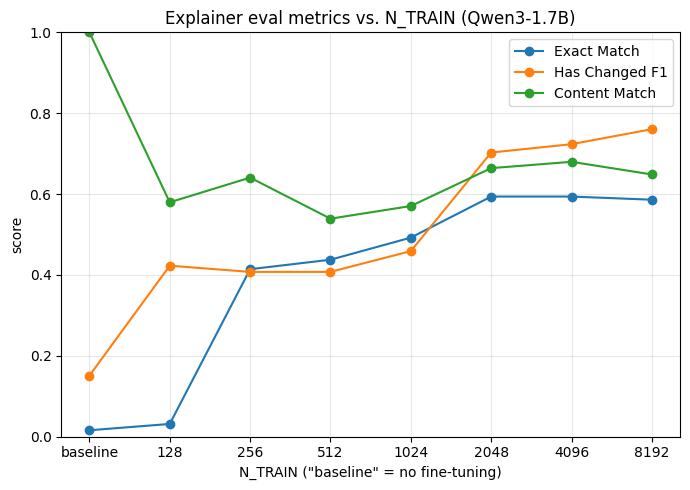

,n_train,exact_match,has_changed_f1,content_match,unparseable_rate
baseline,base,0.015625,0.150671,1.000000,0.984375
128,128,0.031250,0.422724,0.579545,0.312500
256,256,0.414062,0.407407,0.640625,0.000000
512,512,0.437500,0.407407,0.539062,0.000000
1024,1024,0.492188,0.458834,0.570312,0.000000
2048,2048,0.593750,0.702659,0.664062,0.000000
4096,4096,0.593750,0.723312,0.679688,0.000000
8192,8192,0.585938,0.760461,0.648438,0.000000


In [16]:
import matplotlib.pyplot as plt

# order rows: baseline first, then n_train sizes ascending; skip anything not yet evaluated
order = ["baseline"] + [f"{n}" for n in sorted(N_TRAIN_VALUES[:-1])]
order = [k for k in order if k in all_scores]

eval_df = pd.DataFrame([all_scores[k] for k in order], index=order)
eval_df.to_csv(f"/content/drive/MyDrive/{OUTPUT_DIR}/eval_summary.csv")  # summary CSV for reproducing figures outside the notebook

metrics_to_plot = ["exact_match", "has_changed_f1", "content_match"]

fig, ax = plt.subplots(figsize=(7, 5))
for metric in metrics_to_plot:
    ax.plot(eval_df.index, eval_df[metric], marker="o", label=metric.replace("_", " ").title())

ax.set_xlabel('N_TRAIN ("baseline" = no fine-tuning)')
ax.set_ylabel("score")
ax.set_ylim(0, 1)
ax.set_title(f"Explainer eval metrics vs. N_TRAIN ({MODEL_ID})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

eval_df

## Activation Patching

Activation patching is a causal method in mechanistic interpretability. It involves generating answers to two similar prompts, and then swapping internal activations between them to see how the responses change. If $P_1$, $P_2$ are prompts, one may insert $v^1_{\ell,t}$ (the $t$-th tokens vector representation at layer $\ell$) and inserting it into the response to $P_2$ by replacing $v^2_{\ell, t} \mapsto v^1_{\ell,t}$.

For example if $P_1$ is "The color of the sky is blue" and $P_2$ is "The color of wood is brown", we would replace the embedded "sky" token with an activation of "wood".

Here we train the explainer model to predict the results of an activation patching experiment in natural language as described below.

Per section 2.3 and appendix F, the user turn prompts  with one of several templates (randomly sampled), each describing a feature `[s]v[e]` (a placeholder token span standing in for the patched activation vector) added at a preset layer range and token position while processing text `x`:

> If feature [s]v[e] at layer ℓ is added to tokens xt when processing the text <<<x>>>, how would the output change?
>
> When feature [s]v[e] at layer ℓ is added at tokens xt in the input <<<x>>>, what happens to the model's output?
>
> Consider the input text: <<<x>>>. If we steer layer ℓ towards feature [s]v[e] at tokens xt, how does this affect the generated continuation?
>
> Given the text <<<x>>>, what would be the effect on the output if feature [s]v[e] at layer ℓ is added to tokens xt?
>
> If we steer towards feature [s]v[e] at layer ℓ and tokens xt when processing <<<x>>>, how would the model's response differ?

The assistant turn reports the model's actual observed continuation under the patch, $M(x; h_{\ell1:i,t}(x) ← \operatorname{avg}(h_{\ell_{1:i,t}}(x')))$, in the same two-branch form as input ablation:

> The most likely output would change to <<<$M(x; h_{\ell1:i,t}(x) ← \operatorname{avg}(h_{\ell_{1:i,t}}(x')))$>>>.
>
> The output would remain unchanged from <<<$M(x; h_{\ell1:i,t}(x) ← \operatorname{avg}(h_{\ell_{1:i,t}}(x')))$>>>.

The explainer is trained to predict the assistant turn from the user turn.

We do change from a straight replication. `act_patch_qwen3_8b_counterfact` records activations captured from Qwen3-8B no matter which model we train as the explainer. Instead of using `MODEL_ID = "Qwen3-8B"` so the injected vector `v` already matches the explainer's embedding dimension we keep `MODEL_ID` small for compute reasons (e.g. `Qwen3-0.6B`) and instead learn a linear projection, following section 2.2's treatment of hidden-size mismatch (eq. 3):

> For explainer models whose hidden dimension do not match the target model's, we introduce a linear projection Π_ℓ ∈ R^{d_E × d_M} from the target model hidden size d_M to the explainer model hidden size d_E, which is trained jointly with the rest of LM parameters. We learn a separate projection per layer ℓ of the target model.


### Config and datasets

In [17]:
# --- config additions for the small-explainer + projection variant ---
from transformers import AutoConfig

TARGET_MODEL_ID = "Qwen/Qwen3-8B"  # model act_patch_qwen3_8b_counterfact's activations were captured from
# config only (no weights) -- cheap, and enough to size the projection
TARGET_HIDDEN_SIZE = AutoConfig.from_pretrained(TARGET_MODEL_ID).hidden_size

N_LAYER_CHUNKS = 4          # matches the paper's 4-chunk patching protocol (footnote 4, §2.3)

EXPLAINER_HIDDEN_SIZE = model.config.hidden_size
print(f"target hidden size (Qwen3-8B): {TARGET_HIDDEN_SIZE}, explainer hidden size ({MODEL_ID}): {EXPLAINER_HIDDEN_SIZE}")

target hidden size (Qwen3-8B): 4096, explainer hidden size (Qwen3-1.7B): 2048


In [18]:
# activation patching, loading pretrained model outputs (dataset is independent of explainer size)
act_dataset = load_dataset("Transluce/act_patch_qwen3_8b_counterfact", split="train")
act_dataset = act_dataset.shuffle(seed=SEED)  # avoid bias from generation order (e.g. grouped by layer window or source fact)
act_example = act_dataset[0]
print(act_example.keys())

README.md:   0%|          | 0.00/3.11k [00:00<?, ?B/s]

dict_keys(['layer', 'input_tokens', 'original_continuation', 'ablated_continuation', 'is_different', 'patch_position', 'counterfactual_text', 'gt_original_target', 'gt_counterfactual_target', 'layer_hashable', 'token_type', '__index_level_0__'])


### Prompt templates

In [20]:
import random
rng = random.Random(SEED)

ACTIVATION_TEMPLATES = [
    "If feature {feat} at layer {layer} is added to tokens {xt} when processing the text <<<{x}>>>, how would the output change?",
    "When feature {feat} at layer {layer} is added at tokens {xt} in the input <<<{x}>>>, what happens to the model's output?",
    "Consider the input text: <<<{x}>>>. If we steer layer {layer} towards feature {feat} at tokens {xt}, how does this affect the generated continuation?",
    "Given the text <<<{x}>>>, what would be the effect on the output if feature {feat} at layer {layer} is added to tokens {xt}?",
    "If we steer towards feature {feat} at layer {layer} and tokens {xt} when processing <<<{x}>>>, how would the model's response differ?",
]

def format_layer_range(layers):
    """
    python indexing to natural language
    """
    return str(layers[0] if len(layers) == 1 else f"{layers[0]}-{layers[-1]}")

def build_activation_user_turn(layers, xt, x):
    """
    choosing random user prompt
    """
    template = rng.choice(ACTIVATION_TEMPLATES)
    return template.format(feat=FEATURE_SPAN, layer=format_layer_range(layers), xt=xt, x=x)

def build_activation_target_next(original_text, ablated_text):
    """
    explainer returns
    """
    if original_text != ablated_text:
        return f"The most likely output would change to <<<{ablated_text}>>>."
    else:
        return f"The output would remain unchanged from <<<{original_text}>>>."

def build_activation_example(example):
    """
    Build the example in plain text from tokens in dataset
    """
    input_text = tokenizer.convert_tokens_to_string(example["input_tokens"])
    xt = tokenizer.convert_tokens_to_string([example["patch_position"]["orig_text_token"]])
    original_text = "".join(example["original_continuation"])
    ablated_text = "".join(example["ablated_continuation"])
    return(
        build_activation_user_turn(example["layer"], xt, input_text),
        build_activation_target_next(original_text, ablated_text)
    )

def chunk_id_for_layers(layers):
    """
    Map a dataset example's layer range (e.g. [0..8]) to a projection index in [0, N_LAYER_CHUNKS).
    """
    return int(layers[0] // 9)

# lets see what it looks like
print(build_activation_example(act_example))

def to_activation_message(example):
    user_turn, target_next = build_activation_example(example)
    return {
        "messages": [
            {"role": "user", "content": user_turn},
            {"role": "assistant", "content": target_next},
        ],
        "chunk_id": chunk_id_for_layers(example["layer"]),
    }
act_dataset = act_dataset.select(range(40000)) # takes too long to map all 120k examples, and never using more than 8192 (alr shuffled)
act_dataset = act_dataset.map(to_activation_message)

('If feature <|feat_s|><|patch_v|><|feat_e|> at layer 0-8 is added to tokens  unknown when processing the text <<<<|im_start|>user\nSabriel performs\n\nRespond with one of trance or disco or orchestra or fantasy or anthology or unknown and nothing else<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\n>>>, how would the output change?', 'The output would remain unchanged from <<<fant>>>.')


Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

### Learned Projection Π_ℓ

Per section 3.1, when the explainer's hidden size $d_E$ doesn't match the target's $d_M$, a linear map $\Pi_\ell \in \mathbb{R}^{d_E \times d_M}$ is trained alongisde the rest of the explainer's parameters. We insert $\Pi_\ell v$ instead of $v$ at `<patch_v>`. There is one $\Pi$ per layer chunk (`N_LAYER_CHUNKS = 4`) rather than per raw target layer, since a chunk's activations are already averaged into a single vector before injection (see the markdown cell above above). It is randomly initialized.

In [21]:
import torch.nn as nn

class ActivationProjection(nn.Module):
    """projector from eq. (3): one nn.Linear(TARGET_HIDDEN_SIZE, EXPLAINER_HIDDEN_SIZE, bias=False)
    per layer chunk. forward(v, chunk_ids) projects a batch of target-model activation vectors
    into the explainer's embedding space so they can be scattered in place of <|patch_v|>.
    """

    def __init__(self, target_hidden_size, explainer_hidden_size, n_chunks):
        super().__init__()
        self.linears = nn.ModuleList([nn.Linear(target_hidden_size, explainer_hidden_size, bias = False) for n in range(n_chunks)])
        self.n_chunks = n_chunks

    # projection operator applied independently to chunks of v
    def forward(self, v, chunk_ids):
        weight_dtype = self.linears[0].weight.dtype
        out = v.new_empty(v.shape[0], self.linears[0].out_features, dtype=weight_dtype)
        for i in chunk_ids.unique():
            mask = i == chunk_ids
            out[mask] = self.linears[i](v[mask].to(weight_dtype))
        return out

In [22]:
def pretrain_projection_by_regression(explainer_model, projection, text_samples, target_model_id=TARGET_MODEL_ID):
   """
   training the linear projection sending the intervention vector into smaller explainer model
   """
   target_model = AutoModelForCausalLM.from_pretrained(
      target_model_id,
      quantization_config=bnb_config if USE_4BIT else None,
      torch_dtype=None if USE_4BIT else compute_dtype,
      device_map="auto",
      )

   projection.to(compute_dtype)
   # tokenizing
   target_inputs = tokenizer(text_samples, return_tensors="pt", padding=True).to(target_model.device)
   explainer_inputs = tokenizer(text_samples, return_tensors="pt", padding=True).to(explainer_model.device)

   target_mask = target_inputs["attention_mask"].bool()
   explainer_mask = explainer_inputs["attention_mask"].bool()

   # forward pass of each model
   with torch.no_grad():
      target_out = target_model(**target_inputs, output_hidden_states = True)

   with torch.no_grad():
      explainer_out = explainer_model(**explainer_inputs, output_hidden_states = True)

   # function getting layers for each chunk
   def chunks_to_layers(outs, n_chunks):
      layers = outs[1:] # dropping embedding output layer
      L = len(layers)
      base, remainder = divmod(L, n_chunks)
      chunks, start = [], 0
      for c in range(n_chunks):
         size = base + (1 if c < remainder else 0)
         chunks.append(layers[start:start + size])
         start += size
      return chunks

   # extracting layers in target and explainer
   target_layers = chunks_to_layers(target_out.hidden_states, projection.n_chunks)
   explainer_layers = chunks_to_layers(explainer_out.hidden_states, projection.n_chunks)

   # averaging over chunks layers x [B,T,H] -> chunks [B,T,H] tensors
   target_chunk_avg = [torch.stack(chunk).mean(dim = 0) for chunk in target_layers]
   explainer_chunk_avg = [torch.stack(chunk).mean(dim = 0) for chunk in explainer_layers]

   # masking to not train the projection on padding tokens
   target_chunk_avg_masked = [chunk[target_mask] for chunk in target_chunk_avg]
   explainer_chunk_avg_masked = [chunk[explainer_mask] for chunk in explainer_chunk_avg]

   # flattening averaged to chunks [B x T, H]
   target_flat = torch.cat(target_chunk_avg_masked, dim = 0)
   target_rows_per_chunk = target_chunk_avg_masked[0].shape[0]
   target_chunk_ids = torch.arange(projection.n_chunks, device = target_flat.device).repeat_interleave(target_rows_per_chunk)

   explainer_flat = torch.cat(explainer_chunk_avg_masked, dim = 0)

   # learning projection
   criterion = nn.MSELoss()
   optimizer = torch.optim.Adam(projection.linears.parameters(), lr=0.05)

   for epoch in range(500):
      optimizer.zero_grad()
      predictions = projection.forward(target_flat, target_chunk_ids)
      loss = criterion(explainer_flat, predictions)
      loss.backward()
      optimizer.step()

   del target_model
   torch.cuda.empty_cache()

   return projection

### Training Setup (Small Explainer + Projection)

`<|patch_v|>`'s embedding must be replaced before every forward pass with `Π_ℓ v` so tokenization/collation need to carry `chunk_id` alongside `intervention_vector`, and `Trainer.compute_loss` needs to route through `model.activation_projection`.

In [23]:
def build_inputs_embeds_projected(model, projection, input_ids, intervention_vectors, chunk_ids):
    """Like the original build_inputs_embeds, but runs intervention_vectors through
    projection(v, chunk_ids) before scattering into the <|patch_v|> position -- vectors arrive in
    target-model space (dim TARGET_HIDDEN_SIZE) and must land in explainer-embedding space
    (dim EXPLAINER_HIDDEN_SIZE) before assignment.
    """
    input_embeds = model.get_input_embeddings()(input_ids)
    mask = (input_ids == placeholder_id).unsqueeze(-1) # marking placeholder tokens to replace
    v = projection(intervention_vectors, chunk_ids)
    input_embeds.masked_scatter(mask, v.to(input_embeds.dtype))

    return input_embeds


def tokenize_activation_example_with_chunk(example):
    """Similar input-ablation tokenizer:
    build prompt/full ids via the chat template, mask everything but the assistant turn,
    carry through intervention_vector (still in target-model space) and chunk_id.
    """

    prompt_ids = tokenizer.apply_chat_template(
        example["messages"][:1], tokenize=True, add_generation_prompt=True, enable_thinking=False
    )["input_ids"] # just the user prompt
    full_ids = tokenizer.apply_chat_template(
        example["messages"], tokenize=True, add_generation_prompt=False, enable_thinking=False
    )["input_ids"] # complete tokenize convo
    labels = [-100] * len(prompt_ids) + full_ids[len(prompt_ids):] #labels for prompt masking

    return {
        "input_ids": full_ids,
        "labels": labels,
        "intervention_vector": example["patch_position"]["intervention_vector"], #hf dataset format
        "chunk_id": example["chunk_id"]
    }

act_dataset = act_dataset.map(tokenize_activation_example_with_chunk)

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

### Collator
Turning dataset of examples into padded tensor to feed into model.

In [24]:
def activation_collator_with_projection(features):
    """Same padding/batching as the original activation_collator, plus a "chunk_id" long tensor
    (one per row) so build_inputs_embeds_projected knows which projector to apply.
    """
    # converting each needed feature to tensor objects
    input_ids = [torch.tensor(f["input_ids"]) for f in features]
    labels = [torch.tensor(f["labels"]) for f in features]

    # padding them to consistent shape
    input_ids = torch.nn.utils.rnn.pad_sequence(
        input_ids, batch_first = True, padding_value = tokenizer.pad_token_id
    )
    labels = torch.nn.utils.rnn.pad_sequence(
            labels, batch_first = True, padding_value = -100
    )
    attention_mask = (input_ids != tokenizer.pad_token_id).long() # do not train on padding

    # ready to go into training function
    return {
        "input_ids": input_ids,
        "labels": labels,
        "attention_mask": attention_mask,
        "intervention_vector": torch.tensor(
            [f["intervention_vector"] for f in features], dtype = compute_dtype
        ),
        "chunk_id": torch.tensor(
            [f["chunk_id"] for f in features], dtype = torch.long
        )
    }

### Training Functions
Special loss module adjusted for activation patching with intervention vector.
Then complete training pipeline.

In [25]:
from transformers import Trainer, TrainingArguments
from peft import get_peft_model, prepare_model_for_kbit_training

ACT_OUTPUT_DIR = f"{OUTPUT_DIR}/activation_patching_projected"  # separate from the 8B-only run's adapters
act_eval_dataset = act_dataset.select(range(len(act_dataset) - EVAL_SIZE, len(act_dataset)))


class ProjectingFeatureInjectingTrainer(Trainer):
    """Like the original FeatureInjectingTrainer, but resolves `model.activation_projection`
    and threads chunk_id through to build_inputs_embeds_projected before the forward pass.
    """
    # loss with projection
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):

        # removing unexpected input keys
        chunk_id = inputs.pop("chunk_id")
        intervention_vector = inputs.pop("intervention_vector")

        # embedding inputs
        input_embeds = build_inputs_embeds_projected(
            model, projection = model.activation_projection, input_ids = inputs["input_ids"],
            intervention_vectors = intervention_vector, chunk_ids = chunk_id
        )

        # model pass
        outputs = model(
            inputs_embeds = input_embeds,
            attention_mask = inputs["attention_mask"],
            labels = inputs["labels"]
        )

        return (outputs.loss, outputs) if return_outputs else outputs.loss

def run_activation_training_small_explainer(n_train):
   """
   Full Activation patching explainer training pipeline
   mirrors the original run_activation_training with the projection wired in.
   """
   tokenizer.padding_side = "right"  # standard for training; switched from "left" set earlier for generation
   train_subset = act_dataset.select(range(n_train))
   base_model = load_fresh_base_model()  # fresh weights each call so LoRA adapters don't stack across runs

   save_dir = f"/content/drive/MyDrive/{ACT_OUTPUT_DIR}/n_train_{n_train}"

   # init projection and add to model
   projection = ActivationProjection(TARGET_HIDDEN_SIZE, EXPLAINER_HIDDEN_SIZE, N_LAYER_CHUNKS)
   projection.to(base_model.device, dtype=compute_dtype)
   base_model.activation_projection = projection
   if USE_4BIT:
      base_model = prepare_model_for_kbit_training(base_model)

   # config LoRA for SFT
   peft_config = LoraConfig(
               r=LORA_R,
               lora_alpha=LORA_R * 2,
               lora_dropout=0.05,
               target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
               modules_to_save=["activation_projection"],
               task_type=TaskType.CAUSAL_LM,
           )

   model = get_peft_model(base_model, peft_config)

   # copied from ablation input sans a few args in TrainingArguments
   trainer = ProjectingFeatureInjectingTrainer(
         model = model,
         args = TrainingArguments(
            output_dir=save_dir, remove_unused_columns=False, # model drops custom fields
            # batching for small dataset (128-8k) and short sequences < 512
            per_device_train_batch_size=4, gradient_accumulation_steps=4,
            # optimizer schedule for LoRA
            learning_rate=1e-4, lr_scheduler_type="cosine", warmup_steps=0.03, optim="paged_adamw_8bit",
            # T4 doesn't support bf16
            bf16=torch.cuda.is_bf16_supported(), fp16=not torch.cuda.is_bf16_supported(),
            gradient_checkpointing=True, gradient_checkpointing_kwargs={"use_reentrant": False},
            # evaluate on the same held-out split every run so N_TRAIN comparisons are apples-to-apples
            eval_strategy="epoch",
            logging_steps=5, save_strategy="no", report_to="none", seed=SEED
         ),
         train_dataset = train_subset,
         eval_dataset = act_eval_dataset,
         data_collator = activation_collator_with_projection)

   train_result = trainer.train()
   eval_metrics = trainer.evaluate()
   trainer.save_model(save_dir)  # saves the LoRA adapter + tokenizer to gdrive (small — not the base model)

   metrics = {"n_train": n_train, **train_result.metrics, **eval_metrics}
   with open(f"{save_dir}/metrics.json", "w") as f:
      json.dump(metrics, f, indent=2)

   del trainer, base_model
   gc.collect()
   torch.cuda.empty_cache()
   return metrics

# single run at the configured N_TRAIN
save_dir = f"/content/drive/MyDrive/{ACT_OUTPUT_DIR}/n_train_{N_TRAIN}"
metrics_path = f"{save_dir}/metrics.json"
if os.path.exists(metrics_path):
    print(f"n_train={N_TRAIN} already done, loading saved metrics")
else:
  print(f"training on {N_TRAIN} examples -> {save_dir}")
  metrics = run_activation_training_small_explainer(N_TRAIN)
  print(metrics)

training on 128 examples -> /content/drive/MyDrive/explanations_interp/Qwen3-1.7B/no_quant/activation_patching_projected/n_train_128


### N_TRAIN Sweep

In [26]:
import pandas as pd
sweep_results = []
for n in N_TRAIN_VALUES:
    save_dir = f"/content/drive/MyDrive/{ACT_OUTPUT_DIR}/n_train_{n}"
    metrics_path = f"{save_dir}/metrics.json"
    if os.path.exists(metrics_path):
        print(f"n_train={n} already done, loading saved metrics")
        with open(metrics_path) as f:
            sweep_results.append(json.load(f))
        continue
    print(f"training on {n} examples -> {save_dir}")
    sweep_results.append(run_activation_training_small_explainer(n))

pd.DataFrame(sweep_results)

training on 128 examples -> /content/drive/MyDrive/explanations_interp/Qwen3-1.7B/no_quant/activation_patching_projected/n_train_128


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,38.691040,1.949622
2,5.073966,0.862626
3,3.472894,0.671080


Training Loss,Validation Loss,Epoch
3.472894,0.671080,3


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:386: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(


...

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,0.423235,0.126167
2,0.345161,0.116977
3,0.262749,0.131385


Training Loss,Validation Loss,Epoch
0.262749,0.131385,3


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:386: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(


,n_train,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss,epoch,eval_loss
0,128,61.6540,6.228,0.389,3.448877e+14,12.442738,3.0,0.671080
1,256,112.1323,6.849,0.428,6.897395e+14,6.694682,3.0,0.184370
2,512,216.5344,7.094,0.443,1.376862e+15,3.806189,3.0,0.177190
3,1024,426.5381,7.202,0.450,2.751393e+15,2.446063,3.0,0.174735
4,2048,845.2952,7.268,0.454,5.508414e+15,1.739635,3.0,0.166441
5,4096,1684.5965,7.294,0.456,1.101948e+16,1.275212,3.0,0.147394
6,8192,3410.8546,7.205,0.450,2.202512e+16,0.962844,3.0,0.161007
7,16384,6840.9480,7.185,0.449,4.407997e+16,0.749064,3.0,0.131385


### Evaluation metrics

Same evaluation metrics as last time

In [27]:
import re
import numpy as np
from peft import PeftModel
from sklearn.metrics import f1_score

ACTIVATION_CONTENT_RE = re.compile(r"<<<(.*?)>>>", re.DOTALL)

def parse_activation_generation(text):
    """
    parser for activation-patching generations: same two-branch verdict as parse_generation,
    but the content inside <<<...>>> is a free-form continuation, not a multiple-choice letter.
    """
    if "would change to" in text:
        verdict = "changed"
    elif "would remain unchanged from" in text:
        verdict = "unchanged"
    else:
        verdict = None  # doesn't match either template phrasing

    match = ACTIVATION_CONTENT_RE.search(text)
    content = match.group(1).strip() if match else None  # no <<<...>>> span found

    return verdict, content


def eval_activation_metrics(eval_dataset, n_train=None, batch_size=16, max_new_tokens=32):
    """
    Same three metrics as eval_metrics, adapted for activation patching:
    Routing through build_inputs_embeds_projected since the prompt contains <|patch_v|>
    "content match" compares generated continuations rather than a multiple-choice letter.
    Set n_train to evaluate a saved adapter, or leave None for the untrained base explainer.
    """
    base_model = load_fresh_base_model()
    # attach an (untrained) projection first
    # activation_projection attribute already present to load the saved modules_to_save weights into
    base_model.activation_projection = ActivationProjection(
        TARGET_HIDDEN_SIZE, EXPLAINER_HIDDEN_SIZE, N_LAYER_CHUNKS
    ).to(base_model.device, dtype=compute_dtype)

    if n_train is not None:
        save_dir = f"/content/drive/MyDrive/{ACT_OUTPUT_DIR}/n_train_{n_train}"
        model = PeftModel.from_pretrained(base_model, save_dir)
    else:
        model = base_model  # no adapter, random projection -> untrained baseline

    model.eval()  # disable LoRA dropout so generations are deterministic
    model.config.use_cache = True
    tokenizer.padding_side = "left"  # every row in a batch must end at the same position for generate() to work

    records = []
    for start in range(0, len(eval_dataset), batch_size):
        batch = eval_dataset[start : start + batch_size]

        prompts = [
            tokenizer.apply_chat_template(m[:1], tokenize=False, add_generation_prompt=True, enable_thinking=False)
            for m in batch["messages"]
        ]
        inputs = tokenizer(prompts, return_tensors="pt", padding=True).to(model.device)

        intervention_vectors = torch.tensor(
            [p["intervention_vector"] for p in batch["patch_position"]], dtype=compute_dtype
        ).to(model.device)
        chunk_ids = torch.tensor(batch["chunk_id"], dtype=torch.long).to(model.device)

        inputs_embeds = build_inputs_embeds_projected(
            model, model.activation_projection, inputs["input_ids"], intervention_vectors, chunk_ids,
        )

        with torch.no_grad():
            output_ids = model.generate(
                inputs_embeds=inputs_embeds,
                attention_mask=inputs["attention_mask"],
                max_new_tokens=max_new_tokens,
                do_sample=False,              # greedy decoding, matches the paper's eval protocol
                pad_token_id=tokenizer.pad_token_id,
            )

        # generate() with inputs_embeds has no discrete input_ids for the prompt to prepend, so
        # output_ids should already be just the new tokens
        generations = tokenizer.batch_decode(output_ids, skip_special_tokens=True)

        for gen_text, is_different, original_continuation, ablated_continuation in zip(
            generations, batch["is_different"], batch["original_continuation"], batch["ablated_continuation"]
        ):
            original_text = "".join(original_continuation)
            ablated_text = "".join(ablated_continuation)

            pred_verdict, pred_content = parse_activation_generation(gen_text)
            records.append({
                "generated_text": gen_text.strip(),
                "target_text": build_activation_target_next(original_text, ablated_text),
                "pred_verdict": pred_verdict,
                "true_verdict": "changed" if is_different else "unchanged",
                "pred_content": pred_content,
                "true_content": ablated_text if is_different else original_text,
            })

    del model, base_model
    gc.collect()
    torch.cuda.empty_cache()

    exact_match = np.mean([
        r["generated_text"].replace(" ", "") == r["target_text"].replace(" ", "") for r in records
    ])

    has_changed_f1 = f1_score(
        [r["true_verdict"] for r in records],
        [r["pred_verdict"] or "unparseable" for r in records],  # unparseable counts as a miss, not a drop
        labels=["changed", "unchanged"],
        average="macro",
    )

    parseable = [r for r in records if r["pred_content"] is not None]
    content_match = np.mean([
        r["pred_content"].replace(" ", "") == r["true_content"].replace(" ", "") for r in parseable
    ]) if parseable else 0.0

    result = {
        "n_train": n_train if n_train is not None else "base",
        "exact_match": exact_match,
        "has_changed_f1": has_changed_f1,
        "content_match": content_match,
        "unparseable_rate": 1 - len(parseable) / len(records),
    }

    # persist metrics + per-example generations to gdrive so figures can be reproduced outside the notebook
    result_dir = f"/content/drive/MyDrive/{ACT_OUTPUT_DIR}/{'baseline' if n_train is None else f'n_train_{n_train}'}"
    os.makedirs(result_dir, exist_ok=True)
    with open(f"{result_dir}/eval_scores.json", "w") as f:
        json.dump(result, f, indent=2)
    with open(f"{result_dir}/eval_records.json", "w") as f:
        json.dump(records, f, indent=2)

    return result


act_scores = eval_activation_metrics(eval_dataset=act_eval_dataset, n_train=N_TRAIN)
print(
    f"Activation-patching explainer scores for {N_TRAIN} examples:\n"
    f"  Exact Match score: {act_scores['exact_match']:.3f}\n"
    f"  Has-Changed F1 score: {act_scores['has_changed_f1']:.3f}\n"
    f"  Content Match score: {act_scores['content_match']:.3f}"
)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Activation-patching explainer scores for 128 examples:
  Exact Match score: 0.227
  Has-Changed F1 score: 0.365
  Content Match score: 0.305


### Baseline Comparison

Baseline here means no fine-tuning at all: `eval_activation_metrics(n_train=None)` attaches a fresh, untrained (randomly-initialized) `ActivationProjection` to the base explainer and skips loading any LoRA adapter. Unlike the input-ablation baseline, this doesn't switch to a differently-worded constrained prompt (there's no `build_baseline_user_turn` equivalent here) -- the untrained model just sees the same chat-template prompt as the trained runs. It's mainly a sanity floor (expect it to score low / be mostly unparseable) rather than a fair best-effort baseline; add a constrained-format prompt variant here if you want a stronger comparison.

In [28]:
act_baseline_scores = eval_activation_metrics(eval_dataset=act_eval_dataset, n_train=None)
print(
    f"Activation-patching explainer scores for the base (no fine-tuning) model:\n"
    f"  Exact Match score: {act_baseline_scores['exact_match']:.3f}\n"
    f"  Has-Changed F1 score: {act_baseline_scores['has_changed_f1']:.3f}\n"
    f"  Content Match score: {act_baseline_scores['content_match']:.3f}"
)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Activation-patching explainer scores for the base (no fine-tuning) model:
  Exact Match score: 0.000
  Has-Changed F1 score: 0.000
  Content Match score: 0.000


### Baseline vs Trained Comparison

Below, we evaluate the activation-patching explainer for each of `N_TRAIN_VALUES`. If you have not already run the training sweep, do so before running the cell below.

In [29]:
# assuming you have already run the baseline and N_TRAIN cells above
act_all_scores = {"baseline": act_baseline_scores,
                   f"{N_TRAIN}": act_scores}

# evaluate any n_train (and baseline) not already covered above
for n in list(N_TRAIN_VALUES) + ["baseline"]:
    key = "baseline" if n == "baseline" else f"{n}"
    if key in act_all_scores:
        continue
    if n == "baseline":
        act_all_scores[key] = eval_activation_metrics(eval_dataset=act_eval_dataset, n_train=None)
    else:
        act_all_scores[key] = eval_activation_metrics(eval_dataset=act_eval_dataset, n_train=n)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Graphing the baseline compared to different `n_train` values.

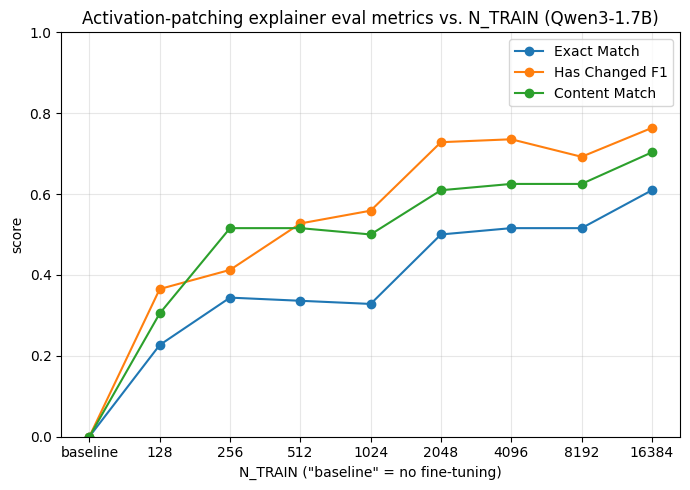

,n_train,exact_match,has_changed_f1,content_match,unparseable_rate
baseline,base,0.000000,0.000000,0.000000,1.0
128,128,0.226562,0.365000,0.304688,0.0
256,256,0.343750,0.412324,0.515625,0.0
512,512,0.335938,0.527223,0.515625,0.0
1024,1024,0.328125,0.558855,0.500000,0.0
2048,2048,0.500000,0.728238,0.609375,0.0
4096,4096,0.515625,0.735469,0.625000,0.0
8192,8192,0.515625,0.692137,0.625000,0.0
16384,16384,0.609375,0.763547,0.703125,0.0


In [30]:
import matplotlib.pyplot as plt

# order rows: baseline first, then n_train sizes ascending; skip anything not yet evaluated
order = ["baseline"] + [f"{n}" for n in sorted(N_TRAIN_VALUES)]
order = [k for k in order if k in act_all_scores]

act_eval_df = pd.DataFrame([act_all_scores[k] for k in order], index=order)
act_eval_df.to_csv(f"/content/drive/MyDrive/{ACT_OUTPUT_DIR}/eval_summary.csv")  # summary CSV for reproducing figures outside the notebook

metrics_to_plot = ["exact_match", "has_changed_f1", "content_match"]

fig, ax = plt.subplots(figsize=(7, 5))
for metric in metrics_to_plot:
    ax.plot(act_eval_df.index, act_eval_df[metric], marker="o", label=metric.replace("_", " ").title())

ax.set_xlabel('N_TRAIN ("baseline" = no fine-tuning)')
ax.set_ylabel("score")
ax.set_ylim(0, 1)
ax.set_title(f"Activation-patching explainer eval metrics vs. N_TRAIN ({MODEL_ID})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

act_eval_df